In [1]:
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.path.join(os.getcwd(), ".."), ".."))
sys.path.append(parent_dir)
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt
from data_generation.models.tech_substitution import TechnologySubstitution
from data_generation.models.tech_substitution import TechSubNumericalSolver
from data_generation.models.general_ode_solver import FitzHughNagumoModel
from data_generation.models.general_ode_solver import GeneralODENumericalSolver
from data_generation.simulations.grid import Grid, tangent_transformation
from data_generation.simulations.simulator import Simulator

In [22]:
bounds = [(0, np.inf), (0, np.inf)]
resolution = [30, 30]
transformations = [tangent_transformation(3, 0.5), tangent_transformation(3, 0.5)]

tech = TechnologySubstitution()
solver = TechSubNumericalSolver(tech)
grid = Grid(bounds, resolution, transformations)

sim = Simulator(grid,tech,solver)

controls = np.array([0.5, 1])

In [29]:
alpha=0.3
method='angular'

importance = sim.calculate_importance_measure(controls,method=method,alpha=alpha, debug=True)

Average angle above diagonal (x2 > x1): 0.05128735829924304
Average angle below diagonal (x2 < x1): 0.33577453548194963
Cell with max angular difference: (20, 17), value: 1.2208563282764342
Located at coordinates: [10.17635999  5.09518912]
This cell is below diagonal


In [30]:
samples_per_cell = sim.importance_to_samples(importance, 20000, min_samples_per_cell=10)

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Cell Importance Measure'}, xlabel='x1', ylabel='x2'>)

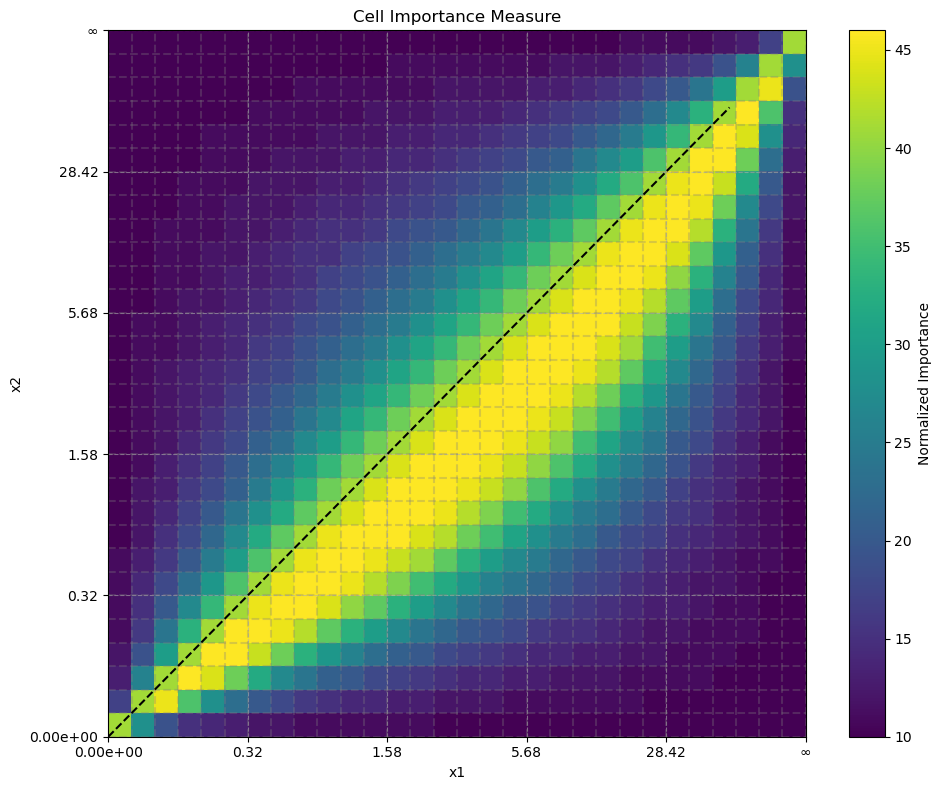

In [31]:
sim.visualize_importance_measure(samples_per_cell)

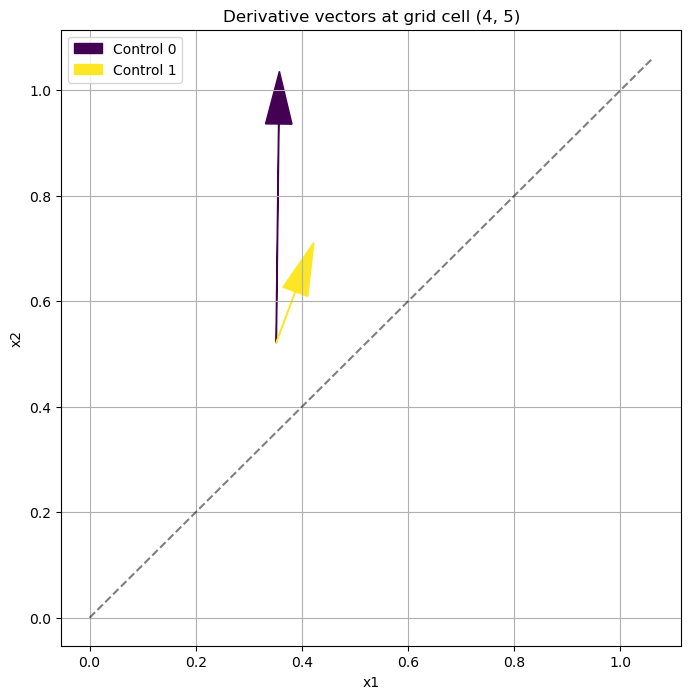

In [6]:
control_values = np.array([[0.5], [1.0]])  

# Choose a grid cell to examine (using the grid indices, not coordinates)
grid_idx = (4, 5)  

# 3. Call the function
fig = sim.visualize_derivatives_at_cell(grid_idx, control_values)
plt.show()

# 4. Save the figure if needed
# fig.savefig(f'derivatives_at_cell_{grid_idx[0]}_{grid_idx[1]}.png')

In [10]:
def test_choose_multiple_random_points_from_cell():
    """Test the choose_multiple_random_points_from_cell function"""
    print("Testing choose_multiple_random_points_from_cell...")
    
    # Create a simple grid
    bounds = [(0, 10), (0, 10)]
    resolution = [5, 5]
    grid = Grid(bounds, resolution)
    
    # Test for a specific cell
    idx = (2, 3)  # Cell in the middle of the grid
    n_samples = 10
    
    # Get cell boundaries
    cell_bounds = [(grid.grid_lines[dim][i], grid.grid_lines[dim][i+1]) 
                  for dim, i in enumerate(idx)]
    print(f"Cell bounds: {cell_bounds}")
    
    # Generate points
    points = grid.choose_multiple_random_points_from_cell(idx, n_samples)
    
    # Check shape
    assert points.shape == (n_samples, 2), f"Expected shape {(n_samples, 2)}, got {points.shape}"
    
    # Check each point is within the cell bounds
    points_in_bounds = True
    for i, point in enumerate(points):
        for dim, (lower, upper) in enumerate(cell_bounds):
            if not lower <= point[dim] <= upper:
                points_in_bounds = False
                print(f"ERROR: Point {i}: {point} is outside bounds {cell_bounds}")
    
    print(f"Generated {n_samples} points: {points}")
    print(f"All points are within the cell boundaries: {points_in_bounds}")
    
    # Test with a transformed grid
    print("\nTesting with transformed grid...")
    transformation = tangent_transformation(3.0, 0.5)
    grid_tf = Grid(bounds, resolution, [transformation, transformation])
    
    # Generate points for the same cell
    points_tf = grid_tf.choose_multiple_random_points_from_cell(idx, n_samples)
    
    # Get cell boundaries in original space
    cell_bounds_tf = [(grid_tf.grid_lines[dim][i], grid_tf.grid_lines[dim][i+1]) 
                     for dim, i in enumerate(idx)]
    print(f"Transformed cell bounds: {cell_bounds_tf}")
    
    # Check each point is within the cell bounds
    points_in_bounds = True
    for i, point in enumerate(points_tf):
        for dim, (lower, upper) in enumerate(cell_bounds_tf):
            if not lower <= point[dim] <= upper:
                points_in_bounds = False
                print(f"ERROR: Point {i}: {point} is outside bounds {cell_bounds_tf}")
    
    print(f"Generated {n_samples} points in transformed space: {points_tf}")
    print(f"All points are within the cell boundaries: {points_in_bounds}")
    
    print("choose_multiple_random_points_from_cell test successful!")

In [12]:

def test_get_importance_based_samples():
    """Test the get_importance_based_samples function"""
    print("\nTesting get_importance_based_samples...")
    
    # Create grid and simulator
    bounds = [(0, 10), (0, 10)]
    resolution = [4, 4]
    grid = Grid(bounds, resolution)
    model = TechnologySubstitution()
    solver = TechSubNumericalSolver(model)
    
    simulator = Simulator(grid, model, solver)
    
    # Create non-uniform importance array
    samples_per_cell = np.ones(resolution, dtype=int)  # Base 1 sample per cell
    samples_per_cell[0, 3] = 5  # Cell (0,3) gets 5 samples
    samples_per_cell[2, 1] = 3  # Cell (2,1) gets 3 samples
    
    total_samples = np.sum(samples_per_cell)
    print(f"Samples per cell:\n{samples_per_cell}")
    print(f"Total samples: {total_samples}")
    
    # Get importance-based samples
    X, trajectory_ids = simulator.get_importance_based_samples(samples_per_cell)
    
    # Check shapes
    assert X.shape == (total_samples, 2), f"Expected X shape {(total_samples, 2)}, got {X.shape}"
    assert len(trajectory_ids) == total_samples, f"Expected {total_samples} IDs, got {len(trajectory_ids)}"
    
    # Check trajectory ID format and count cells
    cell_counts = {}
    for tid in trajectory_ids:
        # Extract cell ID and sample index
        parts = tid.split('_')
        cell_id = parts[0]
        sample_idx = int(parts[1])
        
        # Update the count for this cell
        if cell_id not in cell_counts:
            cell_counts[cell_id] = 0
        cell_counts[cell_id] += 1
        
        # Check sample index is valid
        assert 0 <= sample_idx < cell_counts[cell_id], f"Invalid sample index in {tid}"
    
    print(f"Cell counts: {cell_counts}")
    
    # Check if counts match assigned samples_per_cell
    for idx in grid.indices:
        cell_id = "-".join(map(str, idx))
        expected = samples_per_cell[idx]
        actual = cell_counts.get(cell_id, 0)
        assert expected == actual, f"Cell {cell_id} expected {expected} samples, got {actual}"
    
    # Verify points are in their correct cells
    all_in_bounds = True
    out_of_bounds_points = []
    
    for i, (point, tid) in enumerate(zip(X, trajectory_ids)):
        cell_id = tid.split('_')[0]
        idx = tuple(map(int, cell_id.split('-')))
        
        # Get cell boundaries
        cell_bounds = [(grid.grid_lines[dim][i], grid.grid_lines[dim][i+1]) 
                      for dim, i in enumerate(idx)]
        
        # Check if point is within cell boundaries
        in_bounds = all(lower <= point[dim] <= upper 
                        for dim, (lower, upper) in enumerate(cell_bounds))
        
        if not in_bounds:
            all_in_bounds = False
            out_of_bounds_points.append((i, point, tid, cell_bounds))
    
    if not all_in_bounds:
        print("WARNING: Some points are outside their cell boundaries:")
        for i, point, tid, bounds in out_of_bounds_points[:5]:  # Show at most 5
            print(f"  Point {i}: {point} with ID {tid} is outside {bounds}")
        if len(out_of_bounds_points) > 5:
            print(f"  ... and {len(out_of_bounds_points) - 5} more")
    
    print(f"All points are within their specified cell boundaries: {all_in_bounds}")
    
    print("get_importance_based_samples test successful!")

In [ ]:
def test_compare_with_get_initial_conditions():
    """Compare get_importance_based_samples with get_initial_conditions"""
    print("\nComparing get_importance_based_samples with get_initial_conditions...")
    
    # Create grid and simulator
    bounds = [(0, 10), (0, 10)]
    resolution = [3, 3]
    grid = Grid(bounds, resolution)
    model = TechnologySubstitution()
    solver = TechSubNumericalSolver(model)
    
    simulator = Simulator(grid, model, solver)
    
    # -- Test 1: Use uniform importance (should be equivalent to get_initial_conditions) --
    samples_per_cell = 4  # 4 samples per cell
    uniform_samples_array = np.full(resolution, samples_per_cell)
    
    # Get samples using both methods
    X_init, ids_init = grid.get_initial_conditions(samples_per_cell)
    X_importance, ids_importance = simulator.get_importance_based_samples(uniform_samples_array)
    
    # Check shapes match
    assert X_init.shape == X_importance.shape, f"Shapes don't match: {X_init.shape} vs {X_importance.shape}"
    assert len(ids_init) == len(ids_importance), f"ID counts don't match: {len(ids_init)} vs {len(ids_importance)}"
    
    # Check distribution of points across cells
    init_cell_counts = {}
    for tid in ids_init:
        cell_id = tid.split('_')[0]
        init_cell_counts[cell_id] = init_cell_counts.get(cell_id, 0) + 1
    
    importance_cell_counts = {}
    for tid in ids_importance:
        cell_id = tid.split('_')[0]
        importance_cell_counts[cell_id] = importance_cell_counts.get(cell_id, 0) + 1
    
    cell_counts_match = init_cell_counts == importance_cell_counts
    
    print(f"Both methods generated {len(X_init)} points with {len(init_cell_counts)} cells")
    print(f"Cell distributions match: {cell_counts_match}")
    
    if not cell_counts_match:
        print("Cell count differences:")
        for cell in set(init_cell_counts.keys()) | set(importance_cell_counts.keys()):
            init_count = init_cell_counts.get(cell, 0)
            imp_count = importance_cell_counts.get(cell, 0)
            if init_count != imp_count:
                print(f"  Cell {cell}: init={init_count}, importance={imp_count}")
    
    # -- Test 2: Visual comparison with different sample distributions --
    print("\nVisualizing different sample distributions...")
    
    # Create a varied importance array (higher in top right)
    varied_samples = np.ones(resolution, dtype=int)
    varied_samples[0, 2] = 20  # Top left gets 20 samples
    varied_samples[1, 1] = 10  # Middle gets 10 samples
    
    # Get samples using importance
    X_varied, ids_varied = simulator.get_importance_based_samples(varied_samples)
    
    # Visualize
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Uniform sampling with get_initial_conditions
    plt.subplot(1, 3, 1)
    plt.scatter(X_init[:, 0], X_init[:, 1], s=30, alpha=0.6)
    plt.title(f'get_initial_conditions\n({samples_per_cell} per cell)')
    plt.xlim(bounds[0])
    plt.ylim(bounds[1])
    plt.grid(True)
    
    # Plot 2: Uniform sampling with get_importance_based_samples
    plt.subplot(1, 3, 2)
    plt.scatter(X_importance[:, 0], X_importance[:, 1], s=30, alpha=0.6)
    plt.title(f'get_importance_based_samples\n(uniform: {samples_per_cell} per cell)')
    plt.xlim(bounds[0])
    plt.ylim(bounds[1])
    plt.grid(True)
    
    # Plot 3: Non-uniform sampling with get_importance_based_samples
    plt.subplot(1, 3, 3)
    plt.scatter(X_varied[:, 0], X_varied[:, 1], s=30, alpha=0.6)
    plt.title('get_importance_based_samples\n(non-uniform)')
    plt.xlim(bounds[0])
    plt.ylim(bounds[1])
    plt.grid(True)
    
    # Add grid lines
    for ax in plt.gcf().axes:
        for x in grid.grid_lines[0]:
            ax.axvline(x, color='gray', linestyle='--', alpha=0.3)
        for y in grid.grid_lines[1]:
            ax.axhline(y, color='gray', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('sample_comparison.png')
    print("Visualization saved to 'sample_comparison.png'")
    
    # Check that the distribution matches varied_samples
    varied_cell_counts = {}
    for tid in ids_varied:
        cell_id = tid.split('_')[0]
        varied_cell_counts[cell_id] = varied_cell_counts.get(cell_id, 0) + 1
    
    # Check each cell's count
    varied_matches = True
    for idx in grid.indices:
        cell_id = "-".join(map(str, idx))
        expected = varied_samples[idx]
        actual = varied_cell_counts.get(cell_id, 0)
        if expected != actual:
            varied_matches = False
            print(f"Cell {cell_id} expected {expected} samples, got {actual}")
    
    print(f"Non-uniform distribution matches expectations: {varied_matches}")
    
    print("Comparison complete!")

In [11]:
test_choose_multiple_random_points_from_cell()

Testing choose_multiple_random_points_from_cell...
Cell bounds: [(np.float64(4.0), np.float64(6.0)), (np.float64(6.0), np.float64(8.0))]
Generated 10 points: [[5.29225172 6.61404648]
 [4.11653893 6.82404034]
 [5.28958555 6.5754105 ]
 [5.0767329  7.93888081]
 [4.06015784 6.73762412]
 [5.63161069 7.81127018]
 [5.48520861 6.31167616]
 [5.38091574 7.09535792]
 [5.47369813 7.85787119]
 [5.19100627 7.74328753]]
All points are within the cell boundaries: True

Testing with transformed grid...
Transformed cell bounds: [(np.float64(0.623969999785197), np.float64(1.6757291195215134)), (np.float64(1.6757291195215134), np.float64(3.9788940105131103))]
Generated 10 points in transformed space: [[1.55628306 3.38962338]
 [0.80800183 1.90928682]
 [0.71945571 3.20571318]
 [1.63511124 2.22050372]
 [1.15815262 2.01919191]
 [1.05166516 3.05962547]
 [0.90162928 1.89007236]
 [1.57452782 1.92533996]
 [1.01122064 2.01115079]
 [0.9212036  1.71823184]]
All points are within the cell boundaries: True
choose_mult

In [13]:
test_get_importance_based_samples()


Testing get_importance_based_samples...
Samples per cell:
[[1 1 1 5]
 [1 1 1 1]
 [1 3 1 1]
 [1 1 1 1]]
Total samples: 22
Cell counts: {'0-0': 1, '0-1': 1, '0-2': 1, '0-3': 5, '1-0': 1, '1-1': 1, '1-2': 1, '1-3': 1, '2-0': 1, '2-1': 3, '2-2': 1, '2-3': 1, '3-0': 1, '3-1': 1, '3-2': 1, '3-3': 1}
All points are within their specified cell boundaries: True
get_importance_based_samples test successful!



Comparing get_importance_based_samples with get_initial_conditions...
Both methods generated 36 points with 9 cells
Cell distributions match: True

Visualizing different sample distributions...
Visualization saved to 'sample_comparison.png'
Non-uniform distribution matches expectations: True
Comparison complete!


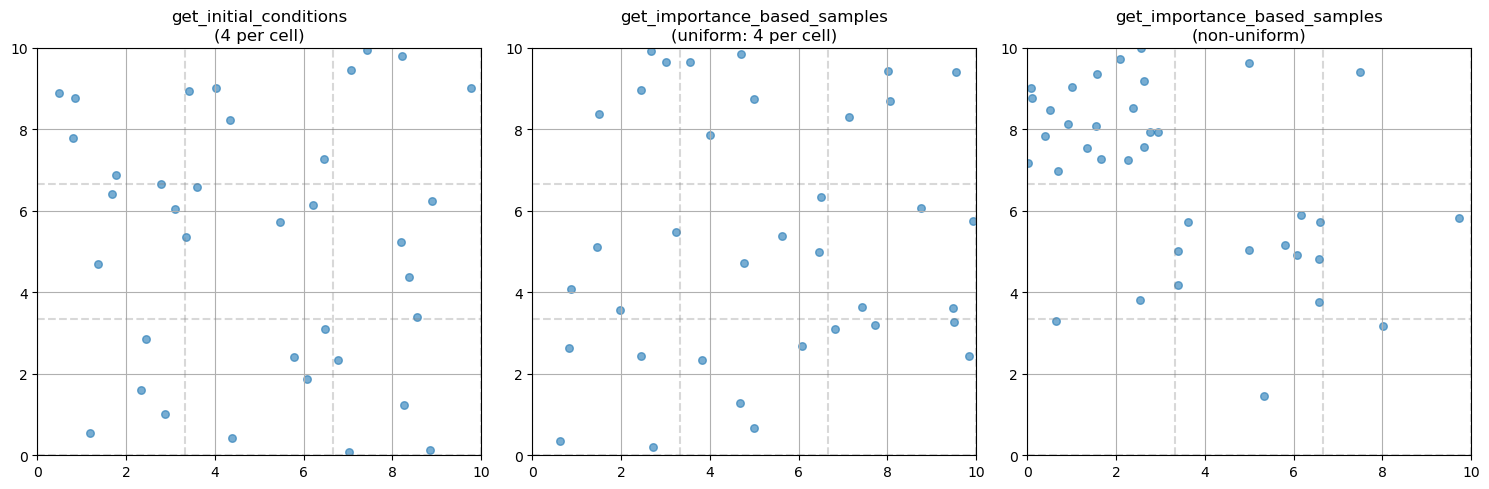

In [17]:
test_compare_with_get_initial_conditions()